In [2]:
MODEL_FILE  = r'C:\\Skripsi_WC\\output\\models\\rfr_watercut_final.pkl'

DATA_FILE   = r'C:\\Skripsi_WC\\data\\DATASET_FINAL_FLAGGED.xlsx'

OUTPUT_FILE = r'C:\\Skripsi_WC\\output\\models\\Hasil_Forecast_WC.xlsx'

SHEETS = ['ESP', 'SRP', 'PCP', 'HPU']

TANGGAL_MULAI = '2026-04-21'

N_HARI = 365

SUMUR_TARGET = ['KAS-52', 'KAS-177', 'KAS-245', 'KAS-147', 'KAS-204']

print("✓ Konfigurasi tersimpan")
print(f"  Model        : {MODEL_FILE}")
print(f"  Data historis: {DATA_FILE}")
print(f"  Forecast dari: {TANGGAL_MULAI} selama {N_HARI} hari")
if SUMUR_TARGET:
    print(f"  Sumur target : {SUMUR_TARGET}")
else:
    print(f"  Sumur target : semua sumur")


✓ Konfigurasi tersimpan
  Model        : C:\\Skripsi_WC\\output\\models\\rfr_watercut_final.pkl
  Data historis: C:\\Skripsi_WC\\data\\DATASET_FINAL_FLAGGED.xlsx
  Forecast dari: 2026-04-21 selama 365 hari
  Sumur target : ['KAS-52', 'KAS-177', 'KAS-245', 'KAS-147', 'KAS-204']


In [3]:
import pandas as pd
import numpy as np
import datetime
import joblib
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from scipy.signal import savgol_filter
from openpyxl import load_workbook
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({
    'font.family': 'Arial', 'figure.dpi': 130,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})
print("✓ Library berhasil diimpor")

✓ Library berhasil diimpor


In [4]:
from pathlib import Path

model_path  = Path(MODEL_FILE)
data_path   = Path(DATA_FILE)
output_path = Path(OUTPUT_FILE)
output_path.parent.mkdir(parents=True, exist_ok=True)

if not model_path.exists():
    raise FileNotFoundError(f"❌ Model tidak ditemukan: {model_path}\n"
                            f"   Edit MODEL_FILE di Cell 1")
if not data_path.exists():
    raise FileNotFoundError(f"❌ Data tidak ditemukan: {data_path}\n"
                            f"   Edit DATA_FILE di Cell 1")

print("=" * 55)
print(f"  ✓ Model  : {model_path.name}  ({model_path.stat().st_size/1e6:.1f} MB)")
print(f"  ✓ Data   : {data_path.name}  ({data_path.stat().st_size/1e6:.1f} MB)")
print(f"  ✓ Output : {output_path}")
print(f"  Semua file siap!")

  ✓ Model  : rfr_watercut_final.pkl  (1501.5 MB)
  ✓ Data   : DATASET_FINAL_FLAGGED.xlsx  (17.5 MB)
  ✓ Output : C:\Skripsi_WC\output\models\Hasil_Forecast_WC.xlsx
  Semua file siap!


In [5]:
model = joblib.load(str(model_path))

print("=" * 55)
print("  MODEL BERHASIL DIMUAT")
print("=" * 55)
print(f"  Jenis     : {type(model).__name__}")
print(f"  Pohon     : {model.n_estimators}")
print(f"  max_feat  : {model.max_features}")
print(f"  Fitur     : {model.n_features_in_}")

FEATURES = [
    'FIG BFPD', 'THP', 'CHP', 'SUBM',
    'dP HEAD', 'FLOW_PRODUCTIVITY_PROXY', 'PROD EFF',
    'DEPTH_ESP_NORM', 'PUMP_INTAKE_PROXY', 'DEPTH_SUBM_RATIO',
    'WC_LAG1', 'WC_LAG7', 'WC_LAG14', 'WC_LAG30',
    'WC_ROLL7_MEAN', 'WC_ROLL14_MEAN', 'WC_ROLL30_MEAN',
    'WC_ROLL7_STD', 'WC_ROLL30_STD', 'BFPD_CHANGE7',
    'LIFTING_CODE', 'SPM', 'RPM', 'HZ',
    'HAS_HZ', 'HAS_SPM', 'HAS_RPM', 'HAS_AMP',
]


  MODEL BERHASIL DIMUAT
  Jenis     : RandomForestRegressor
  Pohon     : 200
  max_feat  : 0.4
  Fitur     : 28


In [74]:
def parse_date(v):
    if isinstance(v, (datetime.datetime, datetime.date)):
        return pd.Timestamp(v)
    if isinstance(v, (int, float)) and not isinstance(v, bool):
        if 40000 < float(v) < 60000:
            return pd.Timestamp('1899-12-30') + pd.Timedelta(days=int(v))
    try:    return pd.to_datetime(str(v), dayfirst=True, errors='coerce')
    except: return pd.NaT

def to_num(v):
    try:    return float(str(v).replace(',', '.').strip())
    except: return np.nan

def baca_sheet(wb, sname):
    ws      = wb[sname]
    headers = list(ws.iter_rows(min_row=2, max_row=2, values_only=True))[0]
    rows    = []
    for row in ws.iter_rows(min_row=4, values_only=True):
        if row[0] is None: continue
        r = {'_SHEET': sname}
        for i, col in enumerate(headers):
            if col is None: continue
            col = str(col).strip()
            v   = row[i] if i < len(row) else None
            if col == 'DATE':              r[col] = parse_date(v)
            elif col in ('WELL','LIFTING'): r[col] = str(v).strip() if v else None
            else:                           r[col] = to_num(v)
        rows.append(r)
    frame = pd.DataFrame(rows)
    if 'FIG BFPD' in frame.columns:
        frame = frame[frame['FIG BFPD'].notna() & (frame['FIG BFPD'] > 0)].copy()
    return frame

def buat_fitur_esp(df):
    df['DEPTH_ESP_NORM'] = df['PUMP_INTAKE_PROXY'] = df['DEPTH_SUBM_RATIO'] = 0.0
    esp_mask  = df['LIFTING'] == 'ESP'
    if 'DEPTH ESP' not in df.columns: return df
    depth_max = df.loc[esp_mask, 'DEPTH ESP'].max()
    if pd.isna(depth_max) or depth_max <= 0: return df
    esp_valid = esp_mask & df['DEPTH ESP'].notna() & (df['DEPTH ESP'] > 0)
    df.loc[esp_valid, 'DEPTH_ESP_NORM'] = df.loc[esp_valid, 'DEPTH ESP'] / depth_max
    if 'SUBM' in df.columns:
        m = esp_valid & df['SUBM'].notna()
        fc = (df.loc[m,'DEPTH ESP'] - df.loc[m,'SUBM'].clip(lower=0)).clip(lower=0)
        df.loc[m, 'PUMP_INTAKE_PROXY'] = 0.4335 * 0.9 * (fc * 3.28084)
        m2 = esp_valid & (df['SUBM'] > 0)
        df.loc[m2,'DEPTH_SUBM_RATIO'] = (df.loc[m2,'DEPTH ESP'] / df.loc[m2,'SUBM'].clip(lower=1)).clip(0,100)
    return df

def buat_flow_productivity(df):
    df['FLOW_PRODUCTIVITY_PROXY'] = np.nan
    if 'PI PROXY' not in df.columns: return df
    pi_v = df['PI PROXY'].notna() & (df['PI PROXY'] > 0)
    df.loc[pi_v, 'FLOW_PRODUCTIVITY_PROXY'] = df.loc[pi_v,'FIG BFPD'] / df.loc[pi_v,'PI PROXY']
    df['FLOW_PRODUCTIVITY_PROXY'] = df['FLOW_PRODUCTIVITY_PROXY'].clip(upper=670.0)
    return df

def buat_flag_sensor(df):
    for c in ['HZ','SPM','RPM','AMP']:
        df[f'HAS_{c}'] = df[c].notna().astype(int) if c in df.columns else 0
    for c in ['FIG GAS','DT HRS','PROD EFF','FLP']:
        if c in df.columns: df[c] = df[c].fillna(0)
    return df

def filter_data(df):
    for fc in ['FLAG_WC_JUMP','FLAG_BFPD_SPIKE','FLAG_WC_ZERO']:
        if fc in df.columns:
            df = df[df[fc].fillna(0) == 0].copy()
    if 'FIG %WC' in df.columns:
        df = df[(df['FIG %WC'] >= 0) & (df['FIG %WC'] <= 100)].copy()
    if 'dP HEAD' in df.columns:
        df = df[df['dP HEAD'].notna() & (df['dP HEAD'] > -500) & (df['dP HEAD'] < 500)].copy()
    ENC = {'SRP':0,'PCP':1,'ESP':2,'HPU':3,'NF':4}
    df['LIFTING_CODE'] = df['LIFTING'].map(ENC).fillna(-1).astype(int)
    return df[df['LIFTING_CODE'] >= 0].copy()

def buat_wc_smooth(df):
    TARGET = 'WC_SMOOTH'
    df[TARGET] = np.nan
    for well, grp in df.groupby('WELL'):
        arr = grp['FIG %WC'].values; n = len(arr)
        s = pd.Series(arr).interpolate(limit_direction='both').ffill().bfill().fillna(50)
        a = s.values.astype(float)
        if n >= 7:
            w = min(11, n if n%2==1 else n-1); w = max(w,5)
            try: a = np.clip(savgol_filter(a, w, 2), 0, 100)
            except: pass
        df.loc[grp.index, TARGET] = a
    return df, TARGET

print("✓ Semua fungsi helper siap (7 fungsi)")

✓ Semua fungsi helper siap (7 fungsi)


In [75]:
print("=" * 55)
print("  LOAD DATA HISTORIS")
print("=" * 55)

wb  = load_workbook(str(data_path), read_only=True, data_only=True)
dfs = []
for s in SHEETS:
    if s in wb.sheetnames:
        df_s = baca_sheet(wb, s)
        if len(df_s) > 0:
            dfs.append(df_s)
            print(f"  ✓ Sheet {s}: {len(df_s):,} baris")
wb.close()

df_hist = pd.concat(dfs, ignore_index=True)
df_hist = df_hist[df_hist['DATE'].notna() & (df_hist['DATE'].dt.year >= 2019)].copy()
df_hist = df_hist.sort_values(['WELL','DATE']).reset_index(drop=True)

print(f"\n  Total historis : {len(df_hist):,} baris")
print(f"  Jumlah sumur   : {df_hist['WELL'].nunique()}")
print(f"  Periode        : {df_hist['DATE'].min().date()} s/d {df_hist['DATE'].max().date()}")
print(f"  Tanggal akhir historis = tanggal T (basis forecast)")

if SUMUR_TARGET:
    df_hist = df_hist[df_hist['WELL'].isin(SUMUR_TARGET)].copy()
    print(f"\n  Filter sumur target: {SUMUR_TARGET}")
    print(f"  Sisa data: {len(df_hist):,} baris | {df_hist['WELL'].nunique()} sumur")

  LOAD DATA HISTORIS
  ✓ Sheet ESP: 16,179 baris
  ✓ Sheet SRP: 19,830 baris
  ✓ Sheet PCP: 119,238 baris
  ✓ Sheet HPU: 9,280 baris

  Total historis : 164,527 baris
  Jumlah sumur   : 79
  Periode        : 2019-01-01 s/d 2026-04-20
  Tanggal akhir historis = tanggal T (basis forecast)

  Filter sumur target: ['KAS-52', 'KAS-177', 'KAS-245', 'KAS-147', 'KAS-204']
  Sisa data: 13,273 baris | 5 sumur


In [77]:
print("Preprocessing data historis...")

df_hist = buat_fitur_esp(df_hist)
df_hist = buat_flow_productivity(df_hist)
df_hist = buat_flag_sensor(df_hist)
df_hist = filter_data(df_hist)
df_hist = df_hist.sort_values(['WELL','DATE']).reset_index(drop=True)

df_hist, TARGET = buat_wc_smooth(df_hist)

for lag in [1, 7, 14, 30]:
    df_hist[f'WC_LAG{lag}'] = df_hist.groupby('WELL')[TARGET].shift(lag)
for win in [7, 14, 30]:
    df_hist[f'WC_ROLL{win}_MEAN'] = df_hist.groupby('WELL')[TARGET].transform(
        lambda x: x.shift(1).rolling(win, min_periods=3).mean())
    df_hist[f'WC_ROLL{win}_STD']  = df_hist.groupby('WELL')[TARGET].transform(
        lambda x: x.shift(1).rolling(win, min_periods=3).std().fillna(0))
df_hist['BFPD_CHANGE7'] = df_hist.groupby('WELL')['FIG BFPD'].transform(lambda x: x.diff(7))
for col in ['HZ','SPM','RPM','AMP']:
    if col in df_hist.columns: df_hist[col] = df_hist[col].fillna(0)

for f in FEATURES:
    if f not in df_hist.columns: df_hist[f] = 0.0

print(f"✓ Preprocessing selesai: {len(df_hist):,} baris siap")
print(f"✓ Sumur tersedia: {sorted(df_hist['WELL'].unique().tolist())}")

Preprocessing data historis...
✓ Preprocessing selesai: 13,052 baris siap
✓ Sumur tersedia: ['KAS-147', 'KAS-177', 'KAS-204', 'KAS-245', 'KAS-52']


In [78]:
SEED_WINDOW = 35

tanggal_start = pd.Timestamp(TANGGAL_MULAI)

seed_state   = {}
drift_state  = {}   
anchor_state = {}  

def hitung_slope_robust(sebelum, target_col='WC_SMOOTH'):

    def slope_window(n):
        arr = sebelum.tail(n)[target_col].dropna().values
        if len(arr) < 10: return np.nan
        lo, hi = np.percentile(arr, 5), np.percentile(arr, 95)
        arr_w  = np.clip(arr, lo, hi)
        x      = np.arange(len(arr_w))
        s, _   = np.polyfit(x, arr_w, 1)
        return s

    slopes = [slope_window(n) for n in [60, 90, 180, 365]]
    slopes = [s for s in slopes if not np.isnan(s)]
    if not slopes: return 0.0
    return float(np.clip(np.median(slopes), -0.05, 0.05))

for well, grp in df_hist.groupby('WELL'):
    grp_sorted = grp.sort_values('DATE')
    sebelum    = grp_sorted[grp_sorted['DATE'] < tanggal_start]

    if len(sebelum) == 0:
        print(f"  ⚠️  {well}: tidak ada data sebelum {TANGGAL_MULAI} — dilewati")
        continue

    seed = sebelum.tail(SEED_WINDOW).copy()
    gap_hari = (tanggal_start - seed['DATE'].max()).days
    if gap_hari > 7:
        print(f"  ⚠️  {well}: gap seed = {gap_hari} hari")

    seed_state[well] = seed

    # Drift robust (median multi-window, winsorize)
    drift_state[well] = hitung_slope_robust(sebelum, TARGET)

    # Anchor: mean WC 365 hari terakhir (batas realistis jangka panjang)
    anchor_state[well] = float(sebelum.tail(365)[TARGET].mean())

print("=" * 70)
print("  SEED STATE + DRIFT ROBUST + ANCHOR PER SUMUR")
print("=" * 70)
for well, seed in sorted(seed_state.items()):
    last_date  = seed['DATE'].max()
    last_wc    = seed[TARGET].iloc[-1] if TARGET in seed.columns else np.nan
    lifting    = seed['LIFTING'].iloc[-1]
    drift      = drift_state.get(well, 0.0)
    anchor     = anchor_state.get(well, last_wc)
    proj_365   = last_wc + drift * 365 * 0.5 + (anchor - last_wc) * 0.3  # estimasi kasar
    arah       = "↑" if drift > 0.002 else ("↓" if drift < -0.002 else "→")
    print(f"  {well:12s} ({lifting:3s}) | WC={last_wc:.1f}%  "
          f"| Drift={drift:+.5f}%/hr {arah}  "
          f"| Anchor={anchor:.1f}%")

print(f"\n✓ {len(seed_state)} sumur siap di-forecast mulai {TANGGAL_MULAI}")


  SEED STATE + DRIFT ROBUST + ANCHOR PER SUMUR
  KAS-147      (PCP) | WC=85.6%  | Drift=+0.03836%/hr ↑  | Anchor=83.3%
  KAS-177      (PCP) | WC=39.0%  | Drift=-0.02836%/hr ↓  | Anchor=72.9%
  KAS-204      (PCP) | WC=85.1%  | Drift=+0.05000%/hr ↑  | Anchor=77.3%
  KAS-245      (PCP) | WC=80.7%  | Drift=-0.05000%/hr ↓  | Anchor=69.2%
  KAS-52       (PCP) | WC=32.7%  | Drift=+0.05000%/hr ↑  | Anchor=18.6%

✓ 5 sumur siap di-forecast mulai 2026-04-21


In [79]:
STRATEGI = 'trend'

OVERRIDE_MANUAL = {
    # 'KAS-207': {
    #     'FIG BFPD': [85.0, 84.5, 84.0, 83.5, 83.0, 82.5, 82.0,   # minggu 1
    #                  82.0, 81.5, 81.0, 80.5, 80.0, 79.5, 79.0,   # minggu 2
    #                  ...],
    #     'THP': [60]*N_HARI,
    # },
}

KOLOM_OPERASI = ['FIG BFPD', 'THP', 'CHP', 'SUBM', 'dP HEAD',
                  'PROD EFF', 'PI PROXY', 'HZ', 'SPM', 'RPM', 'AMP',
                  'DEPTH ESP', 'FLOW_PRODUCTIVITY_PROXY',
                  'DEPTH_ESP_NORM', 'PUMP_INTAKE_PROXY', 'DEPTH_SUBM_RATIO',
                  'LIFTING_CODE', 'HAS_HZ', 'HAS_SPM', 'HAS_RPM', 'HAS_AMP']

tanggal_start  = pd.Timestamp(TANGGAL_MULAI)
tanggal_range  = pd.date_range(start=tanggal_start, periods=N_HARI, freq='D')
asumsi_dict    = {}   # {well: DataFrame N_HARI baris}

for well, seed in seed_state.items():
    seed_sorted = seed.sort_values('DATE')
    rows = []

    for i, tgl in enumerate(tanggal_range):
        r = {'DATE': tgl, 'WELL': well,
             'LIFTING': seed_sorted['LIFTING'].iloc[-1]}

        for col in KOLOM_OPERASI:
            if col not in seed_sorted.columns:
                r[col] = 0.0
                continue

            if STRATEGI == 'flat':
               
                r[col] = seed_sorted[col].iloc[-1]

            elif STRATEGI == 'trend':
                
                series = seed_sorted[col].dropna().tail(30)
                if len(series) >= 5:
                    x = np.arange(len(series))
                    slope, intercept = np.polyfit(x, series.values, 1)
                    r[col] = np.clip(intercept + slope * (len(series) + i),
                                     series.min() * 0.7,
                                     series.max() * 1.3)
                else:
                    r[col] = seed_sorted[col].iloc[-1] if not seed_sorted[col].isna().all() else 0.0

            elif STRATEGI == 'manual':
                # Strategi B: cek override manual
                if (well in OVERRIDE_MANUAL and
                        col in OVERRIDE_MANUAL[well] and
                        i < len(OVERRIDE_MANUAL[well][col])):
                    r[col] = OVERRIDE_MANUAL[well][col][i]
                else:
                    r[col] = seed_sorted[col].iloc[-1]  # fallback ke flat

        r['HAS_HZ']  = int(seed_sorted['HAS_HZ'].iloc[-1] > 0)
        r['HAS_SPM'] = int(seed_sorted['HAS_SPM'].iloc[-1] > 0)
        r['HAS_RPM'] = int(seed_sorted['HAS_RPM'].iloc[-1] > 0)
        r['HAS_AMP'] = int(seed_sorted['HAS_AMP'].iloc[-1] > 0)
        rows.append(r)

    asumsi_dict[well] = pd.DataFrame(rows)

print(f"✓ Tabel asumsi operasi dibuat (Strategi: {STRATEGI.upper()})")
print(f"  {len(asumsi_dict)} sumur × {N_HARI} hari = {len(asumsi_dict)*N_HARI:,} baris forecast")
print(f"  Periode: {tanggal_range[0].date()} s/d {tanggal_range[-1].date()}")

first_well = list(asumsi_dict.keys())[0]
print(f"\n  Preview asumsi sumur {first_well}:")
preview_cols = ['DATE','FIG BFPD','THP','CHP','dP HEAD','LIFTING']
preview_cols = [c for c in preview_cols if c in asumsi_dict[first_well].columns]
print(asumsi_dict[first_well][preview_cols].head(7).to_string(index=False))

✓ Tabel asumsi operasi dibuat (Strategi: TREND)
  5 sumur × 365 hari = 1,825 baris forecast
  Periode: 2026-04-21 s/d 2027-04-20

  Preview asumsi sumur KAS-147:
      DATE  FIG BFPD  THP  CHP  dP HEAD LIFTING
2026-04-21 78.936894  5.0  0.2    -6.24     PCP
2026-04-22 79.087269  5.0  0.2    -6.24     PCP
2026-04-23 79.237644  5.0  0.2    -6.24     PCP
2026-04-24 79.388019  5.0  0.2    -6.24     PCP
2026-04-25 79.538394  5.0  0.2    -6.24     PCP
2026-04-26 79.688769  5.0  0.2    -6.24     PCP
2026-04-27 79.839144  5.0  0.2    -6.24     PCP


In [80]:
print("=" * 60)
print("  RECURSIVE FORECASTING + ROBUST DRIFT + MEAN REVERSION")
print("=" * 60)

semua_hasil = []

for well in sorted(seed_state.keys()):
    seed      = seed_state[well].sort_values('DATE').copy()
    asumsi_df = asumsi_dict[well]
    lifting   = seed['LIFTING'].iloc[-1]

    drift_base = drift_state.get(well, 0.0)    
    wc_anchor  = anchor_state.get(well, 50.0)  

    wc_hist = seed[TARGET].dropna().values
    if len(wc_hist) >= 7:
        deltas = np.diff(wc_hist)
        
        lo_d, hi_d = np.percentile(deltas, 10), np.percentile(deltas, 90)
        deltas_w   = deltas[(deltas >= lo_d) & (deltas <= hi_d)]
        noise_scale = np.clip(np.std(deltas_w) if len(deltas_w) > 2 else 0.3, 0.05, 1.5)
    else:
        noise_scale = 0.3
 
    wc_buffer   = {}
    bfpd_buffer = {}
    for _, row in seed.iterrows():
        if pd.notna(row.get(TARGET, np.nan)):
            wc_buffer[row['DATE']] = row[TARGET]
        if pd.notna(row.get('FIG BFPD', np.nan)):
            bfpd_buffer[row['DATE']] = row['FIG BFPD']

    wc_fallback = float(np.nanmean(list(wc_buffer.values()))) if wc_buffer else 50.0
    rng         = np.random.default_rng(seed=abs(hash(well)) % (2**31))

    hasil_well = []

    for i, (_, asumsi_row) in enumerate(asumsi_df.iterrows()):
        tgl_pred = asumsi_row['DATE']

        def get_lag(lag_hari):
            tgl_lag = tgl_pred - pd.Timedelta(days=lag_hari)
            for delta in [0, -1, 1, -2, 2]:
                val = wc_buffer.get(tgl_lag + pd.Timedelta(days=delta), np.nan)
                if pd.notna(val): return val
            return wc_fallback

        wc_lag1  = get_lag(1)
        wc_lag7  = get_lag(7)
        wc_lag14 = get_lag(14)
        wc_lag30 = get_lag(30)

        def get_roll_stats(window):
            vals = [wc_buffer.get(tgl_pred - pd.Timedelta(days=d), np.nan)
                    for d in range(1, window + 1)]
            vals = [v for v in vals if pd.notna(v)]
            if len(vals) >= 3:
                return np.mean(vals), (np.std(vals) if len(vals) > 1 else 0.0)
            return wc_fallback, 0.0

        roll7_mean,  roll7_std  = get_roll_stats(7)
        roll14_mean, _          = get_roll_stats(14)
        roll30_mean, roll30_std = get_roll_stats(30)

        bfpd_now     = asumsi_row.get('FIG BFPD', 0)
        bfpd_7ago    = bfpd_buffer.get(tgl_pred - pd.Timedelta(days=7), bfpd_now)
        bfpd_change7 = bfpd_now - bfpd_7ago

        # ── Vektor fitur ──────────────────────────────────────────────
        fitur = {
            'FIG BFPD'               : bfpd_now,
            'THP'                    : asumsi_row.get('THP', 0),
            'CHP'                    : asumsi_row.get('CHP', 0),
            'SUBM'                   : asumsi_row.get('SUBM', 0),
            'dP HEAD'                : asumsi_row.get('dP HEAD', 0),
            'FLOW_PRODUCTIVITY_PROXY': asumsi_row.get('FLOW_PRODUCTIVITY_PROXY', 0),
            'PROD EFF'               : asumsi_row.get('PROD EFF', 1),
            'DEPTH_ESP_NORM'         : asumsi_row.get('DEPTH_ESP_NORM', 0),
            'PUMP_INTAKE_PROXY'      : asumsi_row.get('PUMP_INTAKE_PROXY', 0),
            'DEPTH_SUBM_RATIO'       : asumsi_row.get('DEPTH_SUBM_RATIO', 0),
            'WC_LAG1'    : wc_lag1,  'WC_LAG7'  : wc_lag7,
            'WC_LAG14'   : wc_lag14, 'WC_LAG30' : wc_lag30,
            'WC_ROLL7_MEAN' : roll7_mean,  'WC_ROLL14_MEAN': roll14_mean,
            'WC_ROLL30_MEAN': roll30_mean, 'WC_ROLL7_STD'  : roll7_std,
            'WC_ROLL30_STD' : roll30_std,  'BFPD_CHANGE7'  : bfpd_change7,
            'LIFTING_CODE': asumsi_row.get('LIFTING_CODE', 1),
            'SPM': asumsi_row.get('SPM', 0), 'RPM': asumsi_row.get('RPM', 0),
            'HZ' : asumsi_row.get('HZ', 0),
            'HAS_HZ' : asumsi_row.get('HAS_HZ', 0),
            'HAS_SPM': asumsi_row.get('HAS_SPM', 0),
            'HAS_RPM': asumsi_row.get('HAS_RPM', 0),
            'HAS_AMP': asumsi_row.get('HAS_AMP', 0),
        }

        X_row  = np.array([[fitur[f] for f in FEATURES]])
        wc_rf  = float(np.clip(model.predict(X_row)[0], 0, 100))

        drift_t = drift_base * np.exp(-i / 365)

        wc_current = wc_buffer.get(tgl_pred - pd.Timedelta(days=1), wc_rf)
        reversion  = (wc_anchor - wc_current) * 0.003

        drift_total = drift_t + reversion

        decay      = np.exp(-i / 180)
        daily_noise = rng.normal(0, noise_scale * decay)

        wc_final = float(np.clip(wc_rf + drift_total + daily_noise, 0, 100))

        wc_buffer[tgl_pred]   = wc_final
        bfpd_buffer[tgl_pred] = bfpd_now

        tree_preds = np.array([tree.predict(X_row)[0] for tree in model.estimators_])
        tree_adj   = np.clip(tree_preds + drift_total, 0, 100)
        wc_std  = np.std(tree_adj)
        wc_lo80 = np.clip(np.percentile(tree_adj, 10), 0, 100)
        wc_hi80 = np.clip(np.percentile(tree_adj, 90), 0, 100)
        wc_lo95 = np.clip(np.percentile(tree_adj, 2.5), 0, 100)
        wc_hi95 = np.clip(np.percentile(tree_adj, 97.5), 0, 100)

        hasil_well.append({
            'DATE'         : tgl_pred,
            'WELL'         : well,
            'LIFTING'      : lifting,
            'HARI_KE'      : i + 1,
            'FIG BFPD'     : bfpd_now,
            'THP'          : asumsi_row.get('THP', np.nan),
            'CHP'          : asumsi_row.get('CHP', np.nan),
            'dP HEAD'      : asumsi_row.get('dP HEAD', np.nan),
            'WC_PRED_%'    : round(wc_final, 3),
            'WC_RF_RAW_%'  : round(wc_rf, 3),
            'DRIFT_HARI'   : round(drift_total, 4),
            'WC_STD'       : round(wc_std, 3),
            'WC_LO_80%'    : round(wc_lo80, 3),
            'WC_HI_80%'    : round(wc_hi80, 3),
            'WC_LO_95%'    : round(wc_lo95, 3),
            'WC_HI_95%'    : round(wc_hi95, 3),
            'WC_LAG1_USED' : round(fitur['WC_LAG1'], 3),
        })

    semua_hasil.extend(hasil_well)
    wc1    = hasil_well[0]['WC_PRED_%']
    wc_end = hasil_well[-1]['WC_PRED_%']
    print(f"  ✓ {well:12s} ({lifting:3s}) | Hari1={wc1:.1f}% → Hari{N_HARI}={wc_end:.1f}%  "
          f"[drift={drift_base:+.5f}%/hr  anchor={wc_anchor:.1f}%  noise_σ={noise_scale:.2f}%]")

df_forecast = pd.DataFrame(semua_hasil)
print(f"\n✓ Forecast selesai: {len(df_forecast):,} baris ({df_forecast['WELL'].nunique()} sumur × {N_HARI} hari)")


  RECURSIVE FORECASTING + ROBUST DRIFT + MEAN REVERSION
  ✓ KAS-147      (PCP) | Hari1=85.3% → Hari365=90.6%  [drift=+0.03836%/hr  anchor=83.3%  noise_σ=0.21%]
  ✓ KAS-177      (PCP) | Hari1=39.8% → Hari365=75.2%  [drift=-0.02836%/hr  anchor=72.9%  noise_σ=1.34%]
  ✓ KAS-204      (PCP) | Hari1=85.4% → Hari365=87.6%  [drift=+0.05000%/hr  anchor=77.3%  noise_σ=0.34%]
  ✓ KAS-245      (PCP) | Hari1=81.4% → Hari365=91.4%  [drift=-0.05000%/hr  anchor=69.2%  noise_σ=1.50%]
  ✓ KAS-52       (PCP) | Hari1=33.0% → Hari365=35.4%  [drift=+0.05000%/hr  anchor=18.6%  noise_σ=1.50%]

✓ Forecast selesai: 1,825 baris (5 sumur × 365 hari)


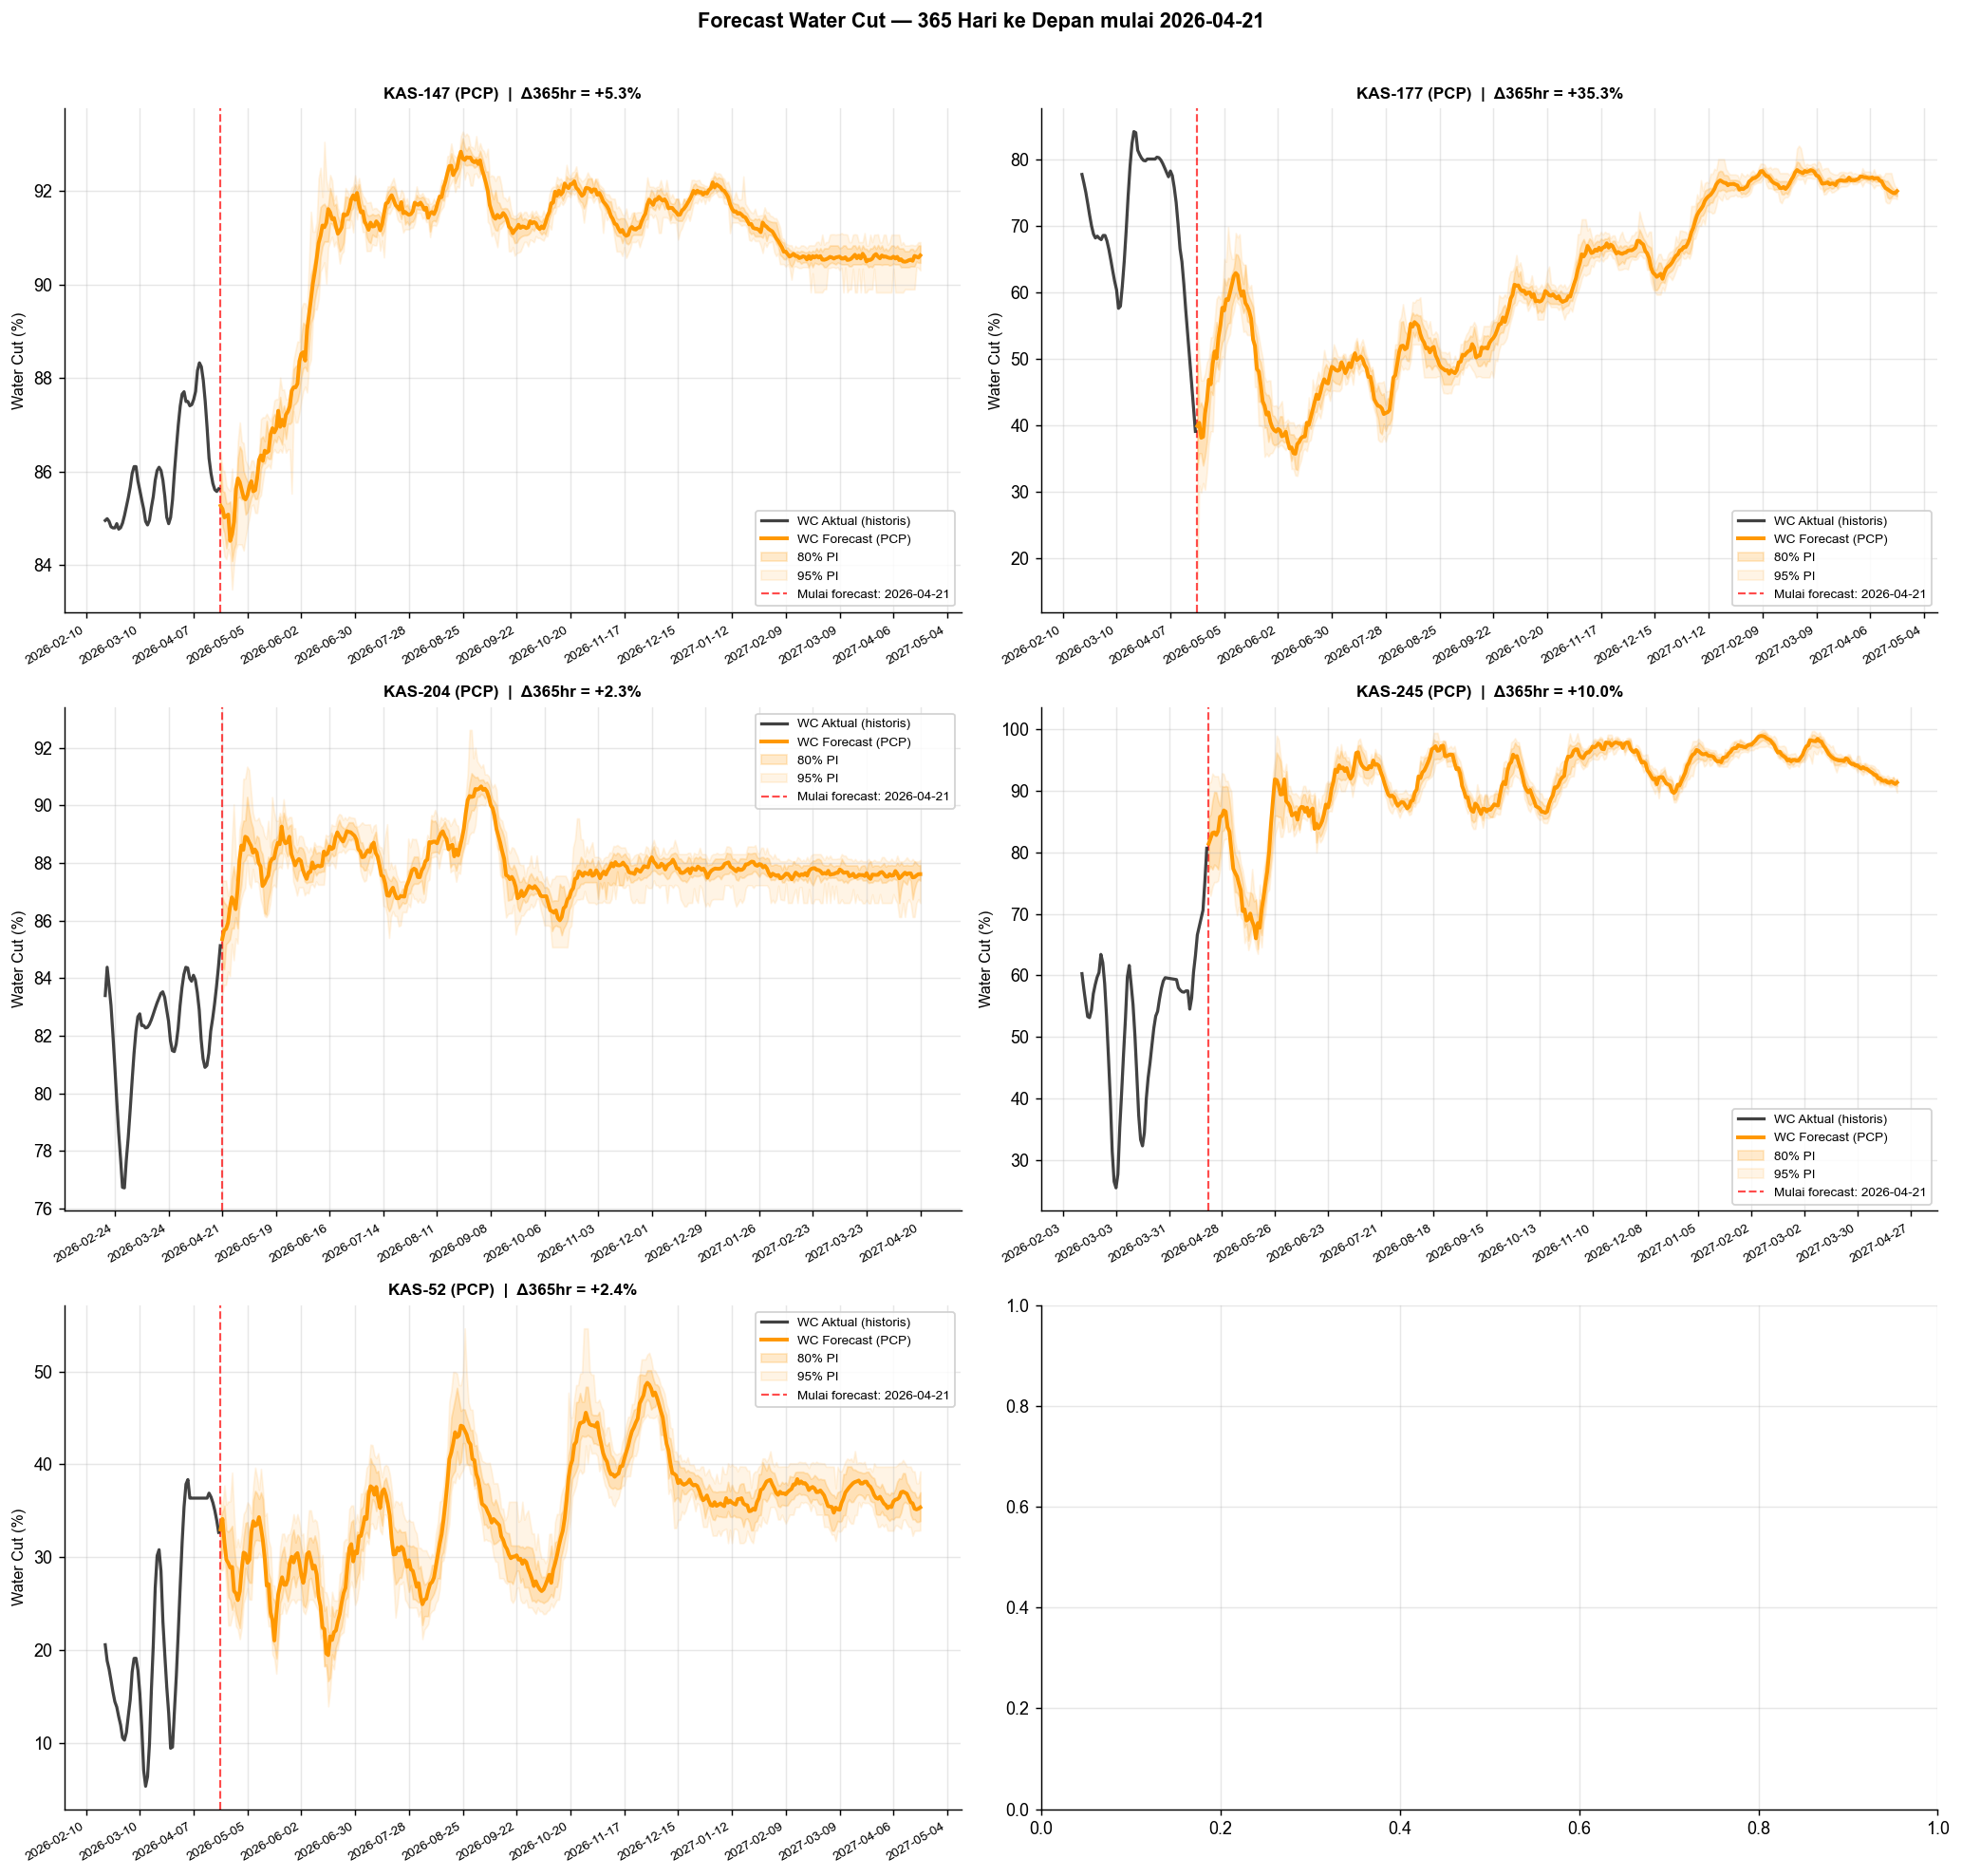

✓ Grafik tersimpan: Fig_Forecast_WC.png


In [82]:
LIFT_COLOR = {'ESP':'#F44336','SRP':'#2196F3','PCP':'#FF9800','HPU':'#4CAF50'}

wells_plot = sorted(df_forecast['WELL'].unique())
n_wells    = len(wells_plot)
ncols      = 2
nrows      = (n_wells + 1) // ncols   

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes_flat  = axes.flat if hasattr(axes, 'flat') else [axes]

for ax, well in zip(axes_flat, wells_plot):
    lifting = df_forecast.loc[df_forecast['WELL']==well, 'LIFTING'].iloc[0]
    color   = LIFT_COLOR.get(lifting, '#666666')

    hist_all  = df_hist[df_hist['WELL']==well].sort_values('DATE')
    cutoff    = pd.Timestamp(TANGGAL_MULAI)
    hist_show = hist_all[hist_all['DATE'] < cutoff].tail(60)
    if TARGET in hist_show.columns and len(hist_show) > 0:
        ax.plot(hist_show['DATE'], hist_show[TARGET],
                color='#212121', lw=1.8, alpha=0.85, zorder=3, label='WC Aktual (historis)')

    fc = df_forecast[df_forecast['WELL']==well].sort_values('DATE')
    ax.plot(fc['DATE'], fc['WC_PRED_%'],
            color=color, lw=2.2, zorder=5, label=f'WC Forecast ({lifting})')
    ax.fill_between(fc['DATE'], fc['WC_LO_80%'], fc['WC_HI_80%'],
                    color=color, alpha=0.20, label='80% PI')
    ax.fill_between(fc['DATE'], fc['WC_LO_95%'], fc['WC_HI_95%'],
                    color=color, alpha=0.10, label='95% PI')

    ax.axvline(cutoff, color='red', lw=1.2, ls='--', alpha=0.7,
               label=f'Mulai forecast: {TANGGAL_MULAI}')

    wc_awal  = fc['WC_PRED_%'].iloc[0]
    wc_akhir = fc['WC_PRED_%'].iloc[-1]
    delta    = wc_akhir - wc_awal
    ax.set_title(f"{well} ({lifting})  |  Δ{N_HARI}hr = {delta:+.1f}%",
                 fontsize=9.5, fontweight='bold')
    ax.set_ylabel('Water Cut (%)', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=4))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7.5)
    ax.legend(fontsize=7.5, loc='best', framealpha=0.85)
    ax.grid(True, alpha=0.3)

for ax in list(axes_flat)[n_wells:]:
    ax.set_visible(False)

plt.suptitle(f"Forecast Water Cut — {N_HARI} Hari ke Depan mulai {TANGGAL_MULAI}",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(Path(OUTPUT_FILE).parent / 'Fig_Forecast_WC.png'),
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Grafik tersimpan: Fig_Forecast_WC.png")


In [83]:
print("=" * 70)
print("  RINGKASAN FORECAST")
print("=" * 70)
print(f"  {'WELL':<14} {'LIFT':<5} {'WC Hari 1':>10} {'WC Hari 7':>10} "
      f"{'WC Hari 30':>11} {'Δ Total':>9} {'Tren'}")
print("-" * 70)

ringkasan_rows = []
for well in sorted(df_forecast['WELL'].unique()):
    fc   = df_forecast[df_forecast['WELL']==well].sort_values('HARI_KE')
    lt   = fc['LIFTING'].iloc[0]
    wc1  = fc['WC_PRED_%'].iloc[0]
    wc7  = fc[fc['HARI_KE']==7]['WC_PRED_%'].values[0] if 7 <= N_HARI else fc['WC_PRED_%'].iloc[-1]
    wc30 = fc['WC_PRED_%'].iloc[-1]
    delta = wc30 - wc1
    tren  = "↑ Naik" if delta > 0.5 else ("↓ Turun" if delta < -0.5 else "→ Stabil")
    print(f"  {well:<14} {lt:<5} {wc1:>9.2f}% {wc7:>9.2f}% {wc30:>10.2f}% {delta:>+8.2f}%  {tren}")
    ringkasan_rows.append({'WELL':well,'LIFTING':lt,
                            'WC_HARI1_%':round(wc1,2),'WC_HARI7_%':round(wc7,2),
                            'WC_HARI30_%':round(wc30,2),'DELTA_%':round(delta,2),'TREN':tren})

df_ringkasan = pd.DataFrame(ringkasan_rows)
print("-" * 70)
print(f"\n  Periode forecast : {TANGGAL_MULAI} + {N_HARI} hari")
print(f"  Strategi asumsi  : {STRATEGI.upper()}")
print(f"  ⚠  Akurasi forecast menurun seiring hari ke depan.")
print(f"     Gunakan hasil ini sebagai estimasi tren, bukan nilai pasti.")

  RINGKASAN FORECAST
  WELL           LIFT   WC Hari 1  WC Hari 7  WC Hari 30   Δ Total Tren
----------------------------------------------------------------------
  KAS-147        PCP       85.28%     84.66%      90.62%    +5.35%  ↑ Naik
  KAS-177        PCP       39.84%     46.80%      75.18%   +35.34%  ↑ Naik
  KAS-204        PCP       85.35%     86.66%      87.61%    +2.26%  ↑ Naik
  KAS-245        PCP       81.41%     85.79%      91.37%    +9.95%  ↑ Naik
  KAS-52         PCP       32.98%     28.94%      35.37%    +2.39%  ↑ Naik
----------------------------------------------------------------------

  Periode forecast : 2026-04-21 + 365 hari
  Strategi asumsi  : TREND
  ⚠  Akurasi forecast menurun seiring hari ke depan.
     Gunakan hasil ini sebagai estimasi tren, bukan nilai pasti.


In [84]:
print("Menyimpan hasil...")

with pd.ExcelWriter(str(output_path), engine='openpyxl') as writer:
    
    df_ringkasan.to_excel(writer, sheet_name='Ringkasan_Forecast', index=False)

    df_out = df_forecast.copy()
    df_out['DATE'] = df_out['DATE'].dt.date
    df_out.to_excel(writer, sheet_name='Detail_Semua', index=False)

    for lt in ['ESP','SRP','PCP','HPU']:
        sub = df_out[df_out['LIFTING']==lt]
        if len(sub) > 0:
            sub.to_excel(writer, sheet_name=f'Detail_{lt}', index=False)

    asumsi_all = pd.concat(asumsi_dict.values(), ignore_index=True)
    asumsi_all['DATE'] = asumsi_all['DATE'].dt.date
    cols_asumsi = ['DATE','WELL','LIFTING','FIG BFPD','THP','CHP','SUBM',
                   'dP HEAD','PROD EFF','HZ','RPM','SPM']
    cols_asumsi = [c for c in cols_asumsi if c in asumsi_all.columns]
    asumsi_all[cols_asumsi].to_excel(writer, sheet_name='Asumsi_Operasi', index=False)

print(f"\n✓ Tersimpan: {output_path}")
print(f"  Sheet 'Ringkasan_Forecast' : {len(df_ringkasan)} sumur")
print(f"  Sheet 'Detail_Semua'       : {len(df_forecast):,} baris")
print(f"  Sheet 'Asumsi_Operasi'     : parameter operasi yang diasumsikan")
print()
print("=" * 55)
print("  SELESAI! Buka file Excel untuk melihat hasil.")
print(f"  Lokasi: {output_path}")
print("=" * 55)

Menyimpan hasil...

✓ Tersimpan: C:\Skripsi_WC\output\models\Hasil_Forecast_WC.xlsx
  Sheet 'Ringkasan_Forecast' : 5 sumur
  Sheet 'Detail_Semua'       : 1,825 baris
  Sheet 'Asumsi_Operasi'     : parameter operasi yang diasumsikan

  SELESAI! Buka file Excel untuk melihat hasil.
  Lokasi: C:\Skripsi_WC\output\models\Hasil_Forecast_WC.xlsx
